# TSP Baseline — Google OR-Tools

This notebook evaluates **Google OR-Tools** as a baseline solver on the TSP validation datasets generated by the data generation notebook.

For each TSP size (10, 20, …, 200) it:
1. Loads the validation instances from Google Drive / local storage
2. Solves a sample of instances in parallel using multi-core worker processes (OR-Tools)
3. Records **tour length**, **wall-clock time**, and **solver status**
4. Reports summary statistics and plots

---
## 1 — Install OR-Tools

In [1]:
!pip install -q ortools

import ortools
print(f"OR-Tools version: {ortools.__version__}")

OR-Tools version: 9.15.6755


---
## 2 — Environment & Google Drive Setup

In [2]:
import os
import sys

# Try loading environment variables from .env if present
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# Detect environment: Colab vs Local
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
RUN_LOCALLY = os.getenv('RUN_LOCALLY', str(not IN_COLAB)).lower() in ('true', '1', 'yes')

if IN_COLAB and not RUN_LOCALLY:
    from google.colab import drive
    drive.mount('/content/drive')
    print('[OK] Google Drive mounted.')
else:
    print(f'[INFO] Running in local mode (RUN_LOCALLY={RUN_LOCALLY}). Using local paths.')

[INFO] Running in local mode (RUN_LOCALLY=True). Using local paths.


---
## 3 — Configuration

In [3]:
import os
import time
import concurrent.futures
import numpy as np
import pandas as pd
import ortools
from tqdm.auto import tqdm

# ── Problem sizes to evaluate ────────────────────────────────────────────────
TSP_SIZES = list(range(10, 201, 10))  # [10, 20, 30, ..., 200]

# ── How many validation instances to solve per size ───────────────────────────
# Solving all 10,000 is slow for large N. Adjust as needed.
NUM_EVAL_INSTANCES = 128  # set to None to solve ALL validation instances

# ── Parallel processing settings ─────────────────────────────────────────────
# Number of parallel CPU workers to use. Set to 1 for sequential execution.
# Defaults to 12 workers (or os.cpu_count() if fewer cores available).
NUM_WORKERS = int(os.getenv('NUM_WORKERS', min(12, os.cpu_count() or 1)))

# ── OR-Tools solver settings ─────────────────────────────────────────────────
# Time limit per instance (seconds). Increase for better solutions on large N.
TIME_LIMIT_SEC = 10

# First solution strategy
# Options: 'PATH_CHEAPEST_ARC', 'CHRISTOFIDES', 'SAVINGS',
#          'SWEEP', 'LOCAL_CHEAPEST_ARC', 'GLOBAL_CHEAPEST_ARC'
FIRST_SOLUTION_STRATEGY = 'PATH_CHEAPEST_ARC'

# Local search metaheuristic
# Options: 'GUIDED_LOCAL_SEARCH', 'SIMULATED_ANNEALING',
#          'TABU_SEARCH', 'GENERIC_TABU_SEARCH'
LOCAL_SEARCH_METAHEURISTIC = 'GUIDED_LOCAL_SEARCH'

# ── Distance scaling factor ──────────────────────────────────────────────────
# OR-Tools uses integer distances. We scale coordinates by this factor
# before rounding. Higher = more precise but larger numbers.
DISTANCE_SCALE = 100_000

# ── Paths ─────────────────────────────────────────────────────────────────────
if RUN_LOCALLY:
    DRIVE_DATA_DIR = os.getenv('TSP_DATA_DIR', './TSP_Data')
    DRIVE_RESULTS_DIR = os.getenv('TSP_RESULTS_DIR', './TSP_Data/baseline_results')
else:
    DRIVE_DATA_DIR = '/content/drive/MyDrive/TSP_Data'
    DRIVE_RESULTS_DIR = '/content/drive/MyDrive/TSP_Data/baseline_results'

os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

# ── Random seed for sampling instances ────────────────────────────────────────
SEED = 42

print(f"TSP sizes         : {TSP_SIZES}")
print(f"Instances per size: {NUM_EVAL_INSTANCES or 'ALL'}")
print(f"Parallel workers  : {NUM_WORKERS} CPUs")
print(f"Time limit/inst   : {TIME_LIMIT_SEC}s")
print(f"First solution    : {FIRST_SOLUTION_STRATEGY}")
print(f"Metaheuristic     : {LOCAL_SEARCH_METAHEURISTIC}")

TSP sizes         : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
Instances per size: 128
Parallel workers  : 12 CPUs
Time limit/inst   : 10s
First solution    : PATH_CHEAPEST_ARC
Metaheuristic     : GUIDED_LOCAL_SEARCH


---
## 4 — Solver Functions

In [4]:
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
from scipy.spatial.distance import cdist


def compute_distance_matrix(coords: np.ndarray, scale: int = DISTANCE_SCALE) -> np.ndarray:
    """
    Compute the pairwise Euclidean distance matrix from 2-D coordinates.

    Coordinates are assumed in [0, 1]. Distances are scaled and rounded to
    integers for OR-Tools.

    Parameters
    ----------
    coords : np.ndarray, shape (n, 2)
    scale  : int, scaling factor

    Returns
    -------
    np.ndarray, shape (n, n), dtype int64
    """
    dist = cdist(coords, coords, metric='euclidean')
    return np.round(dist * scale).astype(np.int64)


def compute_tour_length_euclidean(coords: np.ndarray, tour: list) -> float:
    """
    Compute the true Euclidean tour length (no rounding) for a given tour.

    Parameters
    ----------
    coords : np.ndarray, shape (n, 2), float coordinates in [0, 1]
    tour   : list of node indices (closed tour, last returns to first)

    Returns
    -------
    float : total Euclidean tour length
    """
    tour_coords = coords[tour]
    diffs = np.diff(tour_coords, axis=0)
    segment_lengths = np.sqrt((diffs ** 2).sum(axis=1))
    # Add return edge from last to first
    return_edge = np.sqrt(((tour_coords[-1] - tour_coords[0]) ** 2).sum())
    return float(segment_lengths.sum() + return_edge)


def solve_tsp_ortools(
    coords: np.ndarray,
    time_limit_sec: int = TIME_LIMIT_SEC,
    first_solution_strategy: str = FIRST_SOLUTION_STRATEGY,
    local_search_metaheuristic: str = LOCAL_SEARCH_METAHEURISTIC,
    distance_scale: int = DISTANCE_SCALE,
) -> dict:
    """
    Solve a single TSP instance with OR-Tools.

    Parameters
    ----------
    coords : np.ndarray, shape (n, 2)
    time_limit_sec : int
    first_solution_strategy : str
    local_search_metaheuristic : str
    distance_scale : int

    Returns
    -------
    dict with keys:
        'tour'        : list of node indices
        'tour_length' : float, true Euclidean tour length
        'status'      : str, solver status name
        'wall_time'   : float, seconds elapsed
    """
    n = len(coords)
    dist_matrix = compute_distance_matrix(coords, scale=distance_scale)

    # Create routing model
    manager = pywrapcp.RoutingIndexManager(n, 1, 0)  # 1 vehicle, depot=0
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int(dist_matrix[from_node][to_node])

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Search parameters
    search_params = pywrapcp.DefaultRoutingSearchParameters()

    fss_enum = getattr(
        routing_enums_pb2.FirstSolutionStrategy, first_solution_strategy
    )
    search_params.first_solution_strategy = fss_enum

    lsm_enum = getattr(
        routing_enums_pb2.LocalSearchMetaheuristic, local_search_metaheuristic
    )
    search_params.local_search_metaheuristic = lsm_enum

    search_params.time_limit.FromSeconds(time_limit_sec)

    # Solve
    t0 = time.time()
    solution = routing.SolveWithParameters(search_params)
    wall_time = time.time() - t0

    # Status mapping
    status_map = {
        0: 'ROUTING_NOT_SOLVED',
        1: 'ROUTING_SUCCESS',
        2: 'ROUTING_PARTIAL_SUCCESS',
        3: 'ROUTING_FAIL',
        4: 'ROUTING_FAIL_TIMEOUT',
        5: 'ROUTING_INVALID',
        6: 'ROUTING_INFEASIBLE',
    }
    status = status_map.get(routing.status(), f'UNKNOWN({routing.status()})')

    if solution:
        # Extract tour
        tour = []
        index = routing.Start(0)
        while not routing.IsEnd(index):
            tour.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))

        tour_length = compute_tour_length_euclidean(coords, tour)
    else:
        tour = []
        tour_length = float('inf')

    return {
        'tour': tour,
        'tour_length': tour_length,
        'status': status,
        'wall_time': wall_time,
    }


def _solve_ortools_worker_task(args: tuple) -> tuple:
    """
    Worker task function for parallel execution.

    Parameters
    ----------
    args : tuple
        (instance_idx, coords, time_limit_sec, first_solution_strategy,
         local_search_metaheuristic, distance_scale)

    Returns
    -------
    tuple : (instance_idx, result_dict)
    """
    idx, coords, time_limit_sec, first_sol, metaheuristic, dist_scale = args
    result = solve_tsp_ortools(
        coords=coords,
        time_limit_sec=time_limit_sec,
        first_solution_strategy=first_sol,
        local_search_metaheuristic=metaheuristic,
        distance_scale=dist_scale,
    )
    return idx, result


def solve_tsp_batch_ortools(
    coords_list: list[np.ndarray] | np.ndarray,
    indices: list[int] | np.ndarray = None,
    num_workers: int = NUM_WORKERS,
    time_limit_sec: int = TIME_LIMIT_SEC,
    first_solution_strategy: str = FIRST_SOLUTION_STRATEGY,
    local_search_metaheuristic: str = LOCAL_SEARCH_METAHEURISTIC,
    distance_scale: int = DISTANCE_SCALE,
    desc: str = 'Solving TSP',
) -> list[tuple[int, dict]]:
    """
    Solve a batch of TSP instances in parallel using ProcessPoolExecutor.

    Parameters
    ----------
    coords_list : list of np.ndarray or np.ndarray of shape (B, N, 2)
    indices : list of int, optional instance identifiers
    num_workers : int, number of parallel worker processes
    time_limit_sec : int, solver time limit per instance
    first_solution_strategy : str
    local_search_metaheuristic : str
    distance_scale : int
    desc : str, progress bar description

    Returns
    -------
    list of (instance_idx, result_dict), sorted by instance_idx
    """
    if indices is None:
        indices = list(range(len(coords_list)))

    tasks = [
        (
            idx,
            coords_list[i],
            time_limit_sec,
            first_solution_strategy,
            local_search_metaheuristic,
            distance_scale,
        )
        for i, idx in enumerate(indices)
    ]

    results = []
    if num_workers > 1 and len(tasks) > 1:
        with concurrent.futures.ProcessPoolExecutor(max_workers=num_workers) as executor:
            futures = [executor.submit(_solve_ortools_worker_task, t) for t in tasks]
            with tqdm(total=len(tasks), desc=desc, leave=True) as pbar:
                for future in concurrent.futures.as_completed(futures):
                    results.append(future.result())
                    pbar.update(1)
    else:
        for t in tqdm(tasks, desc=desc, leave=True):
            results.append(_solve_ortools_worker_task(t))

    results.sort(key=lambda x: x[0])
    return results

---
## 5 — Quick Smoke Test

Solve one small instance to verify everything works.

In [5]:
# 1. Single instance smoke test
rng = np.random.default_rng(0)
test_coords = rng.random((10, 2), dtype=np.float32)

result = solve_tsp_ortools(test_coords, time_limit_sec=5)

print('Single instance test:')
print(f"  Tour        : {result['tour']}")
print(f"  Tour length : {result['tour_length']:.6f}")
print(f"  Status      : {result['status']}")
print(f"  Wall time   : {result['wall_time']:.3f}s")

# 2. Parallel batch smoke test
smoke_workers = min(4, NUM_WORKERS)
batch_coords = [rng.random((10, 2), dtype=np.float32) for _ in range(4)]
batch_results = solve_tsp_batch_ortools(
    batch_coords,
    num_workers=smoke_workers,
    time_limit_sec=2,
    desc='Smoke test batch',
)
print(f'\nParallel batch test ({smoke_workers} workers):')
print(f'  Solved {len(batch_results)} instances successfully.')
print('\n[OK] Smoke tests passed!')


Single instance test:
  Tour        : [0, 7, 5, 9, 4, 3, 2, 1, 6, 8]
  Tour length : 3.077853
  Status      : ROUTING_SUCCESS
  Wall time   : 5.001s

Parallel batch test (4 workers):
  Solved 4 instances successfully.

[OK] Smoke tests passed!


---
## 6 — Evaluate All TSP Sizes

For each problem size:
1. Load validation data from Drive
2. Sample `NUM_EVAL_INSTANCES` instances
3. Solve each with OR-Tools
4. Collect statistics

In [6]:
rng = np.random.default_rng(SEED)
all_results = []  # list of dicts per TSP size
per_instance_records = []  # detailed per-instance results

for n in TSP_SIZES:
    val_path = os.path.join(DRIVE_DATA_DIR, f'tsp_{n}', 'val.npy')

    if not os.path.exists(val_path):
        print(f"[WARNING] {val_path} not found — skipping TSP-{n}")
        continue

    val_data = np.load(val_path)  # (10000, n, 2)

    # Sample instances
    if NUM_EVAL_INSTANCES is not None and NUM_EVAL_INSTANCES < len(val_data):
        indices = rng.choice(len(val_data), size=NUM_EVAL_INSTANCES, replace=False)
        indices.sort()
    else:
        indices = np.arange(len(val_data))

    sep_line = '═' * 65
    print(f'\n{sep_line}')
    print(f"  TSP-{n}  |  Solving {len(indices)} instances ({NUM_WORKERS} workers)  |  Time limit: {TIME_LIMIT_SEC}s")
    print(f'{sep_line}')

    t_start = time.time()
    results = solve_tsp_batch_ortools(
        coords_list=val_data[indices],
        indices=indices,
        num_workers=NUM_WORKERS,
        time_limit_sec=TIME_LIMIT_SEC,
        first_solution_strategy=FIRST_SOLUTION_STRATEGY,
        local_search_metaheuristic=LOCAL_SEARCH_METAHEURISTIC,
        distance_scale=DISTANCE_SCALE,
        desc=f'TSP-{n}',
    )
    elapsed_total = time.time() - t_start

    tour_lengths = []
    wall_times = []
    statuses = []

    for idx, res in results:
        tour_lengths.append(res['tour_length'])
        wall_times.append(res['wall_time'])
        statuses.append(res['status'])

        per_instance_records.append({
            'tsp_size': n,
            'instance_idx': int(idx),
            'tour_length': res['tour_length'],
            'wall_time': res['wall_time'],
            'status': res['status'],
        })

    tour_lengths = np.array(tour_lengths)
    wall_times = np.array(wall_times)

    # Count solver statuses
    status_counts = {}
    for s in statuses:
        status_counts[s] = status_counts.get(s, 0) + 1

    summary = {
        'tsp_size': n,
        'num_instances': len(indices),
        'tour_length_mean': float(tour_lengths[tour_lengths < float('inf')].mean()) if (tour_lengths < float('inf')).any() else float('inf'),
        'tour_length_std': float(tour_lengths[tour_lengths < float('inf')].std()) if (tour_lengths < float('inf')).any() else 0.0,
        'tour_length_min': float(tour_lengths[tour_lengths < float('inf')].min()) if (tour_lengths < float('inf')).any() else float('inf'),
        'tour_length_max': float(tour_lengths[tour_lengths < float('inf')].max()) if (tour_lengths < float('inf')).any() else float('inf'),
        'wall_time_mean': float(wall_times.mean()),
        'wall_time_std': float(wall_times.std()),
        'wall_time_total': float(wall_times.sum()),
        'elapsed_time_total': float(elapsed_total),
        'status_counts': status_counts,
        'solved_pct': 100.0 * sum(1 for s in statuses if 'SUCCESS' in s) / len(statuses),
    }
    all_results.append(summary)

    print(f"  Mean tour length : {summary['tour_length_mean']:.6f} ± {summary['tour_length_std']:.6f}")
    print(f"  Mean solve time  : {summary['wall_time_mean']:.3f}s ± {summary['wall_time_std']:.3f}s (per instance)")
    print(f"  Elapsed wall time: {elapsed_total:.1f}s ({NUM_WORKERS} workers) | Total CPU time: {summary['wall_time_total']:.1f}s")
    print(f"  Solver statuses  : {status_counts}")

    del val_data

end_sep = '━' * 65
print(f'\n{end_sep}')
print('   Evaluation complete!')
print(f'{end_sep}')



═════════════════════════════════════════════════════════════════
  TSP-10  |  Solving 128 instances (12 workers)  |  Time limit: 10s
═════════════════════════════════════════════════════════════════
  Mean tour length : 2.911000 ± 0.351500
  Mean solve time  : 10.001s ± 0.001s (per instance)
  Elapsed wall time: 110.2s (12 workers) | Total CPU time: 1280.1s
  Solver statuses  : {'ROUTING_SUCCESS': 128}

═════════════════════════════════════════════════════════════════
  TSP-20  |  Solving 128 instances (12 workers)  |  Time limit: 10s
═════════════════════════════════════════════════════════════════
  Mean tour length : 3.850500 ± 0.279100
  Mean solve time  : 10.001s ± 0.001s (per instance)
  Elapsed wall time: 110.2s (12 workers) | Total CPU time: 1280.1s
  Solver statuses  : {'ROUTING_SUCCESS': 128}

═════════════════════════════════════════════════════════════════
  TSP-30  |  Solving 128 instances (12 workers)  |  Time limit: 10s
═════════════════════════════════════════════════

---
## 7 — Summary Table

In [7]:
summary_df = pd.DataFrame([{
    'TSP Size': r['tsp_size'],
    'Instances': r['num_instances'],
    'Tour Length (mean)': f"{r['tour_length_mean']:.4f}",
    'Tour Length (std)': f"{r['tour_length_std']:.4f}",
    'Tour Length (min)': f"{r['tour_length_min']:.4f}",
    'Tour Length (max)': f"{r['tour_length_max']:.4f}",
    'Time/inst (s)': f"{r['wall_time_mean']:.3f}",
    'Elapsed (s)': f"{r['elapsed_time_total']:.1f}",
    'Total CPU (s)': f"{r['wall_time_total']:.1f}",
    'Solved %': f"{r['solved_pct']:.1f}",
} for r in all_results])

summary_df

TSP Size,Instances,Tour Length (mean),Tour Length (std),Tour Length (min),Tour Length (max),Time/inst (s),Elapsed (s),Total CPU (s),Solved %
10,128,2.9110,0.3515,2.1055,3.7846,10.001,110.2,1280.1,100.0
20,128,3.8505,0.2791,2.9294,4.4693,10.001,110.2,1280.1,100.0
30,128,4.5233,0.2744,3.8085,5.0945,10.000,110.2,1280.1,100.0
40,128,5.1687,0.2631,4.3332,5.7784,10.000,110.2,1280.1,100.0
50,128,5.7484,0.2364,5.1607,6.4298,10.000,110.2,1280.1,100.0
60,128,6.2574,0.2610,5.5374,6.8825,10.000,110.2,1280.1,100.0
70,128,6.7940,0.2850,5.9586,7.5529,10.001,110.1,1280.1,100.0
80,128,7.2121,0.2503,6.4968,7.8807,10.000,110.1,1280.1,100.0
90,128,7.5439,0.2832,6.7522,8.2654,10.000,110.2,1280.0,100.0
100,128,8.0146,0.2256,7.4926,8.6497,10.000,110.2,1280.0,100.0


---
## 8 — Plots

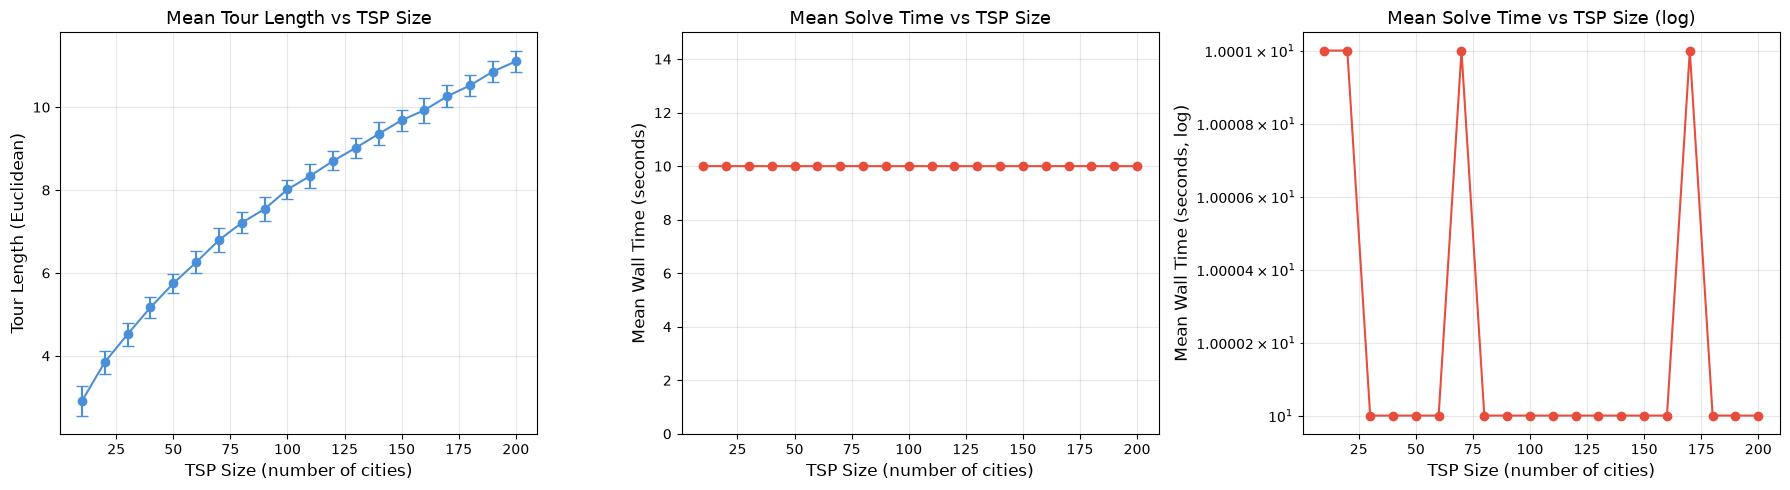

In [8]:
import matplotlib.pyplot as plt

sizes = [r['tsp_size'] for r in all_results]
mean_lengths = [r['tour_length_mean'] for r in all_results]
std_lengths = [r['tour_length_std'] for r in all_results]
mean_times = [r['wall_time_mean'] for r in all_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Mean tour length vs TSP size ──
ax = axes[0]
ax.errorbar(sizes, mean_lengths, yerr=std_lengths,
            fmt='o-', capsize=4, color='#4A90D9', markersize=6)
ax.set_xlabel('TSP Size (number of cities)', fontsize=12)
ax.set_ylabel('Tour Length (Euclidean)', fontsize=12)
ax.set_title('Mean Tour Length vs TSP Size', fontsize=13)
ax.grid(True, alpha=0.3)

# ── Plot 2: Mean solve time vs TSP size ──
ax = axes[1]
ax.plot(sizes, mean_times, 'o-', color='#E74C3C', markersize=6)
ax.set_xlabel('TSP Size (number of cities)', fontsize=12)
ax.set_ylabel('Mean Wall Time (seconds)', fontsize=12)
ax.set_title('Mean Solve Time vs TSP Size', fontsize=13)
ax.set_ylim(bottom=0, top=max(mean_times) * 1.15 if mean_times else 15)
ax.grid(True, alpha=0.3)

# ── Plot 3: Mean solve time (log scale) ──
ax = axes[2]
ax.semilogy(sizes, mean_times, 'o-', color='#E74C3C', markersize=6)
ax.set_xlabel('TSP Size (number of cities)', fontsize=12)
ax.set_ylabel('Mean Wall Time (seconds, log)', fontsize=12)
ax.set_title('Mean Solve Time vs TSP Size (log)', fontsize=13)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

---
## 9 — Tour Length Distribution per Size

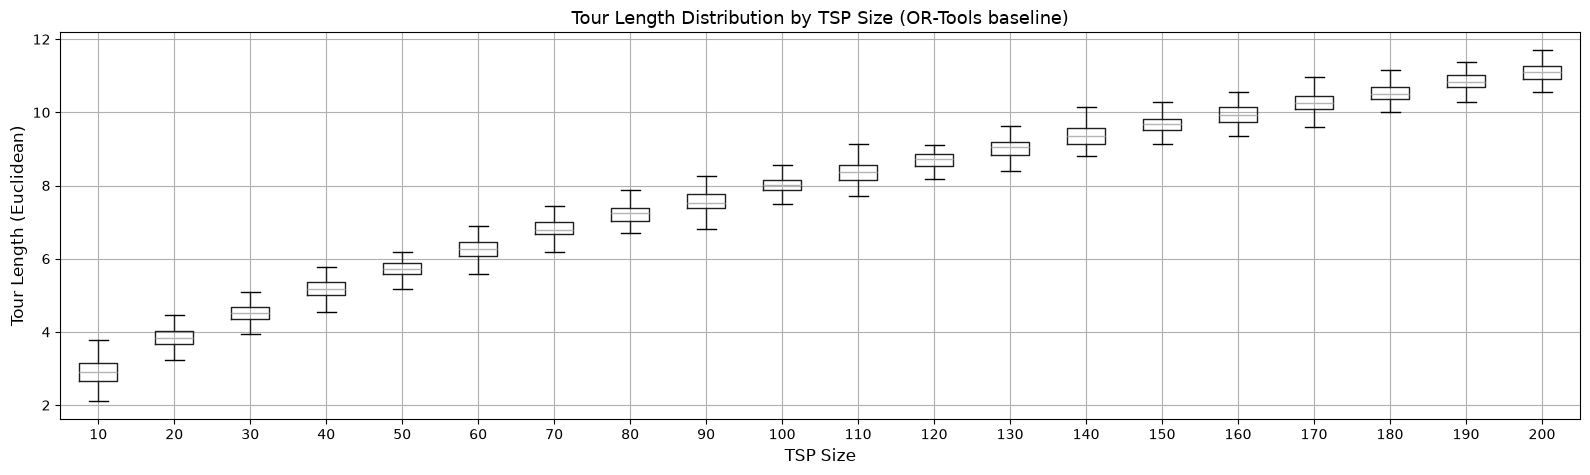

In [9]:
detail_df = pd.DataFrame(per_instance_records)

# Box plot of tour lengths by TSP size
fig, ax = plt.subplots(figsize=(16, 5))
valid_df = detail_df[detail_df['tour_length'] < float('inf')]
valid_df.boxplot(column='tour_length', by='tsp_size', ax=ax,
                 grid=True, showfliers=False)
ax.set_xlabel('TSP Size', fontsize=12)
ax.set_ylabel('Tour Length (Euclidean)', fontsize=12)
ax.set_title('Tour Length Distribution by TSP Size (OR-Tools baseline)', fontsize=13)
fig.suptitle('')  # remove default pandas title
plt.tight_layout()
plt.show()

---
## 10 — Save Results to Google Drive

In [10]:
os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

# ── Per-instance results ──
detail_path = os.path.join(DRIVE_RESULTS_DIR, 'ortools_per_instance.csv')
detail_df.to_csv(detail_path, index=False)
print(f"[OK] Saved per-instance results → {detail_path}")

# ── Summary results ──
summary_path = os.path.join(DRIVE_RESULTS_DIR, 'ortools_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f"[OK] Saved summary → {summary_path}")

# ── Per-instance NumPy arrays (for easy loading in training scripts) ──
for n in set(detail_df['tsp_size']):
    mask = detail_df['tsp_size'] == n
    lengths = detail_df.loc[mask, 'tour_length'].values.astype(np.float32)
    npy_path = os.path.join(DRIVE_RESULTS_DIR, f'ortools_lengths_tsp_{n}.npy')
    np.save(npy_path, lengths)

print(f"[OK] Saved per-size .npy tour lengths → {DRIVE_RESULTS_DIR}/")

# ── Config snapshot for reproducibility ──
config = {
    'tsp_sizes': TSP_SIZES,
    'num_eval_instances': NUM_EVAL_INSTANCES,
    'num_workers': NUM_WORKERS,
    'time_limit_sec': TIME_LIMIT_SEC,
    'first_solution_strategy': FIRST_SOLUTION_STRATEGY,
    'local_search_metaheuristic': LOCAL_SEARCH_METAHEURISTIC,
    'distance_scale': DISTANCE_SCALE,
    'seed': SEED,
    'ortools_version': ortools.__version__,
}
import json
config_path = os.path.join(DRIVE_RESULTS_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"[OK] Saved config → {config_path}")

[OK] Saved per-instance results → ./TSP_Data/baseline_results/ortools_per_instance.csv
[OK] Saved summary → ./TSP_Data/baseline_results/ortools_summary.csv
[OK] Saved per-size .npy tour lengths → ./TSP_Data/baseline_results/
[OK] Saved config → ./TSP_Data/baseline_results/config.json


---
## 11 — Optimality Report

Print a summary of solver optimality across all sizes.

- **ROUTING_SUCCESS** → solver found a solution (optimal for small instances,
  heuristic for larger ones with time limits)
- **ROUTING_FAIL_TIMEOUT** → time limit reached; solution is best-found, not
  necessarily optimal

In [11]:
print(f"{'TSP Size':>10} {'Solved':>8} {'Timeout':>8} {'Failed':>8} {'Solved %':>10}")
print('─' * 50)

for r in all_results:
    sc = r['status_counts']
    solved = sc.get('ROUTING_SUCCESS', 0) + sc.get('ROUTING_PARTIAL_SUCCESS', 0)
    timeout = sc.get('ROUTING_FAIL_TIMEOUT', 0)
    failed = r['num_instances'] - solved - timeout
    pct = 100.0 * solved / r['num_instances']
    print(f"{r['tsp_size']:>10} {solved:>8} {timeout:>8} {failed:>8} {pct:>9.1f}%")

print('─' * 50)
total_inst = sum(r['num_instances'] for r in all_results)
total_solved = sum(r['status_counts'].get('ROUTING_SUCCESS', 0) + r['status_counts'].get('ROUTING_PARTIAL_SUCCESS', 0) for r in all_results)
total_timeout = sum(r['status_counts'].get('ROUTING_FAIL_TIMEOUT', 0) for r in all_results)
total_failed = total_inst - total_solved - total_timeout
total_pct = 100.0 * total_solved / total_inst
print(f"{'TOTAL':>10} {total_solved:>8} {total_timeout:>8} {total_failed:>8} {total_pct:>9.1f}%")


  TSP Size   Solved  Timeout   Failed   Solved %
──────────────────────────────────────────────────
        10      128        0        0     100.0%
        20      128        0        0     100.0%
        30      128        0        0     100.0%
        40      128        0        0     100.0%
        50      128        0        0     100.0%
        60      128        0        0     100.0%
        70      128        0        0     100.0%
        80      128        0        0     100.0%
        90      128        0        0     100.0%
       100      128        0        0     100.0%
       110      128        0        0     100.0%
       120      128        0        0     100.0%
       130      128        0        0     100.0%
       140      128        0        0     100.0%
       150      128        0        0     100.0%
       160      128        0        0     100.0%
       170      128        0        0     100.0%
       180      128        0        0     100.0%
       190      12

---
## 12 — Visualise a Solved Tour

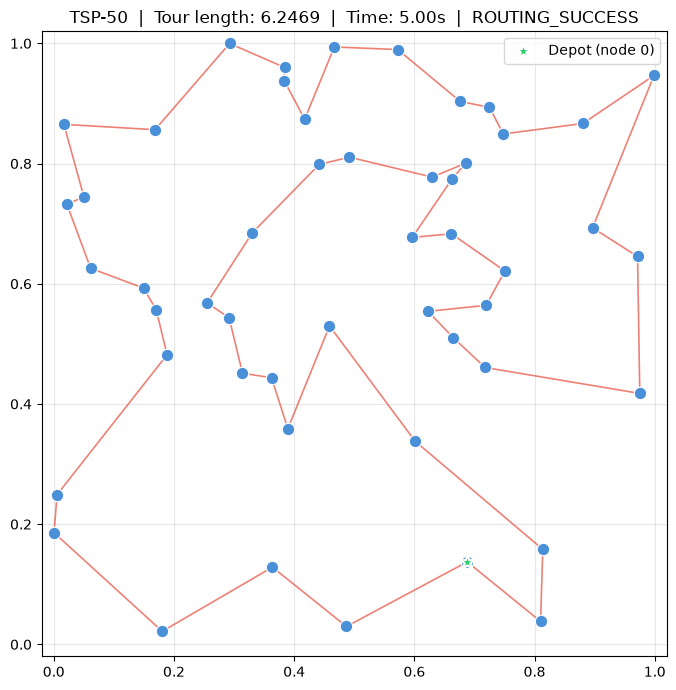

In [12]:
# Solve and plot one instance for visual inspection
viz_n = 50
viz_path = os.path.join(DRIVE_DATA_DIR, f'tsp_{viz_n}', 'val.npy')

if os.path.exists(viz_path):
    viz_data = np.load(viz_path)
    viz_idx = 0
    coords = viz_data[viz_idx]

    result = solve_tsp_ortools(coords, time_limit_sec=30)
    tour = result['tour']

    fig, ax = plt.subplots(figsize=(7, 7))

    # Draw tour edges
    tour_closed = tour + [tour[0]]
    tour_coords = coords[tour_closed]
    ax.plot(tour_coords[:, 0], tour_coords[:, 1],
            '-', color='#E74C3C', linewidth=1.2, alpha=0.7, zorder=2)

    # Draw nodes
    ax.scatter(coords[:, 0], coords[:, 1],
               c='#4A90D9', s=80, edgecolors='white', linewidths=0.8, zorder=3)

    # Label depot
    ax.scatter(coords[0, 0], coords[0, 1],
               c='#2ECC71', s=120, edgecolors='white', linewidths=1.5,
               zorder=4, marker='*', label='Depot (node 0)')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.set_title(
        f'TSP-{viz_n}  |  Tour length: {result["tour_length"]:.4f}  |  '
        f'Time: {result["wall_time"]:.2f}s  |  {result["status"]}',
        fontsize=12
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] {viz_path} not found.")

---
## Output Structure

```
MyDrive/TSP_Data/baseline_results/
├── config.json                       # solver config snapshot
├── ortools_summary.csv               # summary stats per TSP size
├── ortools_per_instance.csv          # per-instance tour lengths & times
├── ortools_lengths_tsp_10.npy        # tour lengths array for TSP-10
├── ortools_lengths_tsp_20.npy
├── ...
└── ortools_lengths_tsp_200.npy
```

### Using results as baseline in your ML training

```python
import numpy as np

# Load baseline tour lengths for TSP-50
baseline = np.load('baseline_results/ortools_lengths_tsp_50.npy')  # (128,)

# Compute gap of your model vs OR-Tools
model_lengths = ...  # your model's predicted tour lengths
gap = (model_lengths - baseline) / baseline * 100  # percentage gap
print(f"Mean gap vs OR-Tools: {gap.mean():.2f}%")
```